### Load necessary libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from nltk.corpus import stopwords
stp_words = stopwords.words("english")
import emoji
import contractions
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import re

### Data Loading

In [68]:
df = pd.read_csv(r"C:\Users\91891\Downloads\Combined Data.csv")
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [69]:
df = df.drop(columns={"Unnamed: 0"})

In [70]:
df.shape

(53043, 2)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53043 non-null  object
dtypes: object(2)
memory usage: 828.9+ KB


In [72]:
df["status"].value_counts()

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

In [73]:
df = df.dropna().reset_index(drop = True)

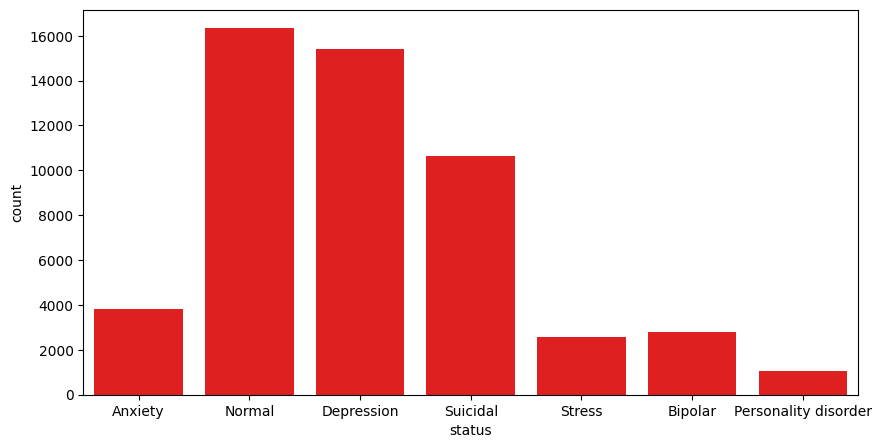

In [74]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="status",color = "red")
plt.show()

### Preprocessing

In [75]:
# chat words
# added some acronyms related to mental health
file_path = r"C:\Users\91891\Downloads\slang.txt"
with open(file_path,"r") as file:
    a = file.readlines()
clean = [i.strip() for i in a]
clean

['A3=Anytime, Anywhere, Anyplace',
 'ADIH=Another Day In Hell',
 'AFK=Away From Keyboard',
 'AFAIK=As Far As I Know',
 'ASAP=As Soon As Possible',
 'ASL=Age, Sex, Location',
 'ATK=At The Keyboard',
 'ATM=At The Moment',
 'BAE=Before Anyone Else',
 'BAK=Back At Keyboard',
 'BBL=Be Back Later',
 'BBS=Be Back Soon',
 'BFN=Bye For Now',
 'B4N=Bye For Now',
 'BRB=Be Right Back',
 'BRUH=Bro',
 'BRT=Be Right There',
 'BSAAW=Big Smile And A Wink',
 'BTW=By The Way',
 'BWL=Bursting With Laughter',
 'CSL=Canâ€™t Stop Laughing',
 'CU=See You',
 'CUL8R=See You Later',
 'CYA=See You',
 'DM=Direct Message',
 'FAQ=Frequently Asked Questions',
 'FC=Fingers Crossed',
 'FIMH=Forever In My Heart',
 'FOMO=Fear Of Missing Out',
 'FR=For Real',
 "FWIW=For What It's Worth",
 'FYP=For You Page',
 'FYI=For Your Information',
 'G9=Genius',
 'GAL=Get A Life',
 'GG=Good Game',
 'GMTA=Great Minds Think Alike',
 'GN=Good Night',
 'GOAT=Greatest Of All Time',
 'GR8=Great!',
 'HBD=Happy Birthday',
 'IC=I See',
 'ICQ=

In [76]:
# connverting to a dictionary
chat_d = {i.split("=")[0].lower() : i.split("=")[1].lower() for i in clean}

In [77]:
def chat_words(sentence):
    chat = []
    for i in sentence.split():
        if i in chat_d:
            chat.append(chat_d[i])
        else:
            chat.append(i)
    return " ".join(chat)

In [78]:
def pre(sentence):
    # lower
    sentence = sentence.lower()

    # contractions can't to cannot
    sentence = contractions.fix(sentence)

    # handling emojis
    sentence = emoji.demojize(sentence)

    # remove non-ascii characters like Â±
    sentence = sentence.encode("ascii","ignore").decode("ascii")
    
    # ':red_heart:' - red heart
    sentence = sentence.replace(":","").replace("_"," ")

    # chat words
    sentence = chat_words(sentence)

    # removed punctuation
    sentence = "".join([i for i in sentence if i not in string.punctuation])
    
    # removed stop words
    sentence = " ".join([w for w in sentence.split() if w not in stp_words])

    # remove digits
    sentence = re.sub(r'\b\d+\b','',sentence)

    # remove words with length <= 2
    sentence = " ".join([w for w in sentence.split() if len(w) > 2])
    
    return sentence

In [79]:
df["cleaned_statement"] = df["statement"].apply(lambda x:pre(x))

In [80]:
# tokens
df["tokens"] = df["cleaned_statement"].apply(word_tokenize)

### Lemmatization

In [81]:
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    lemmas = [lemmatizer.lemmatize(token,pos="v") for token in tokens]
    return " ".join(lemmas)
df["lemmatized_sentence"] = df["tokens"].apply(lemmatize_tokens)

In [82]:
df

,statement,status,cleaned_statement,tokens,lemmatized_sentence
0,oh my gosh,Anxiety,gosh,[gosh],gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...,"[trouble, sleeping, confused, mind, restless, ...",trouble sleep confuse mind restless heart tune
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...,"[wrong, back, dear, forward, doubt, stay, rest...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,shifted focus something else still worried,"[shifted, focus, something, else, still, worried]",shift focus something else still worry
4,"I'm restless and restless, it's been a month n...",Anxiety,restless restless month boy mean,"[restless, restless, month, boy, mean]",restless restless month boy mean
...,...,...,...,...,...
52676,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety,nobody takes seriously 24m dealt depressionanx...,"[nobody, takes, seriously, 24m, dealt, depress...",nobody take seriously 24m deal depressionanxie...
52677,"selfishness ""I don't feel very good, it's lik...",Anxiety,selfishness feel good like belong world think ...,"[selfishness, feel, good, like, belong, world,...",selfishness feel good like belong world think ...
52678,Is there any way to sleep better? I can't slee...,Anxiety,way sleep better cannot sleep nights medicatio...,"[way, sleep, better, can, not, sleep, nights, ...",way sleep better can not sleep nights medicati...
52679,"Public speaking tips? Hi, all. I have to give ...",Anxiety,public speaking tips give presentation work ne...,"[public, speaking, tips, give, presentation, w...",public speak tip give presentation work next w...


In [83]:
# See top 50 words across entire corpus
cv = CountVectorizer(max_features=50)
cv.fit_transform(df["lemmatized_sentence"])
print(cv.get_feature_names_out())

['always' 'anxiety' 'anymore' 'anyone' 'anything' 'back' 'can' 'could'
 'day' 'depression' 'end' 'even' 'eye' 'feel' 'friends' 'fuck' 'get' 'go'
 'good' 'help' 'know' 'life' 'like' 'live' 'love' 'make' 'much' 'need'
 'never' 'not' 'one' 'people' 'really' 'say' 'see' 'something' 'start'
 'still' 'take' 'talk' 'tear' 'tell' 'things' 'think' 'try' 'want' 'way'
 'work' 'would' 'years']


In [84]:
# here i removed some words from top 50 most frequent words across the entire corpus
# because they appeared equally across all categroies, they carry no discriminative meaning
# ex: words like "get", "go", "day", "would", they appear in every category,
# keeping them would make all wordclouds look identical.

custom_stopwords = {'always','anymore','anyone','anything','back','can','could',
 'day','end','even', 'eye', 'feel','friends','get','go',
 'good','help','know', 'life', 'like', 'live', 'make', 'much', 'need',
 'never', 'not', 'one', 'people', 'really' ,'say', 'see', 'something', 'start',
 'still', 'take', 'talk','tell' ,'things' ,'think' ,'try', 'want', 'way',
 'work', 'would', 'years','love','tear','come'}

In [85]:
df["lemmatized_sentence"] = df["lemmatized_sentence"].apply(lambda x: " ".join([w for w in x.split() if w not in custom_stopwords]))

In [86]:
cv = CountVectorizer(max_features = 500)
cv_matrix = cv.fit_transform(df["lemmatized_sentence"])
feature_names = cv.get_feature_names_out()
feature_names

array(['able', 'absolutely', 'abuse', 'accept', 'act', 'actually',
       'advice', 'affect', 'afford', 'afraid', 'age', 'ago', 'alive',
       'allow', 'almost', 'alone', 'already', 'also', 'amount', 'amp',
       'angry', 'another', 'answer', 'anxiety', 'anxious', 'anyway',
       'appreciate', 'around', 'ask', 'attack', 'attempt', 'attention',
       'avoid', 'away', 'awful', 'bad', 'barely', 'basically', 'bear',
       'become', 'bed', 'begin', 'behind', 'believe', 'best', 'better',
       'big', 'bipolar', 'bite', 'blame', 'blood', 'body', 'bore',
       'bother', 'boyfriend', 'brain', 'break', 'breathe', 'bring',
       'brother', 'build', 'burden', 'buy', 'call', 'calm', 'cancer',
       'car', 'care', 'case', 'cause', 'chance', 'change', 'check',
       'chest', 'child', 'choose', 'class', 'clean', 'close', 'college',
       'commit', 'completely', 'consider', 'constant', 'constantly',
       'continue', 'control', 'convince', 'country', 'couple', 'course',
       'crazy', 'cry

In [87]:
df1 = pd.DataFrame(cv_matrix.toarray(),columns=feature_names)
df1

,able,absolutely,abuse,accept,act,actually,advice,affect,afford,afraid,...,worse,worst,worth,write,wrong,year,yes,yesterday,yet,young
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52676,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
52677,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
52678,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
52679,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [88]:
tf = TfidfVectorizer(max_features=500)
df2 = pd.DataFrame(tf.fit_transform(df["lemmatized_sentence"]).toarray(),columns=tf.get_feature_names_out())
df2

,able,absolutely,abuse,accept,act,actually,advice,affect,afford,afraid,...,worse,worst,worth,write,wrong,year,yes,yesterday,yet,young
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.470133,0.000000,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.081215,0.0,0.0,0.101853,0.0
52677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.170483,0.0,0.0,...,0.120931,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
52678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0
52679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0


In [89]:
categories = df["status"].value_counts().index
categories

Index(['Normal', 'Depression', 'Suicidal', 'Anxiety', 'Bipolar', 'Stress',
       'Personality disorder'],
      dtype='object', name='status')

In [90]:
d = {}
for i in categories:
    d[i] = " ".join(df["lemmatized_sentence"][df["status"] == i])

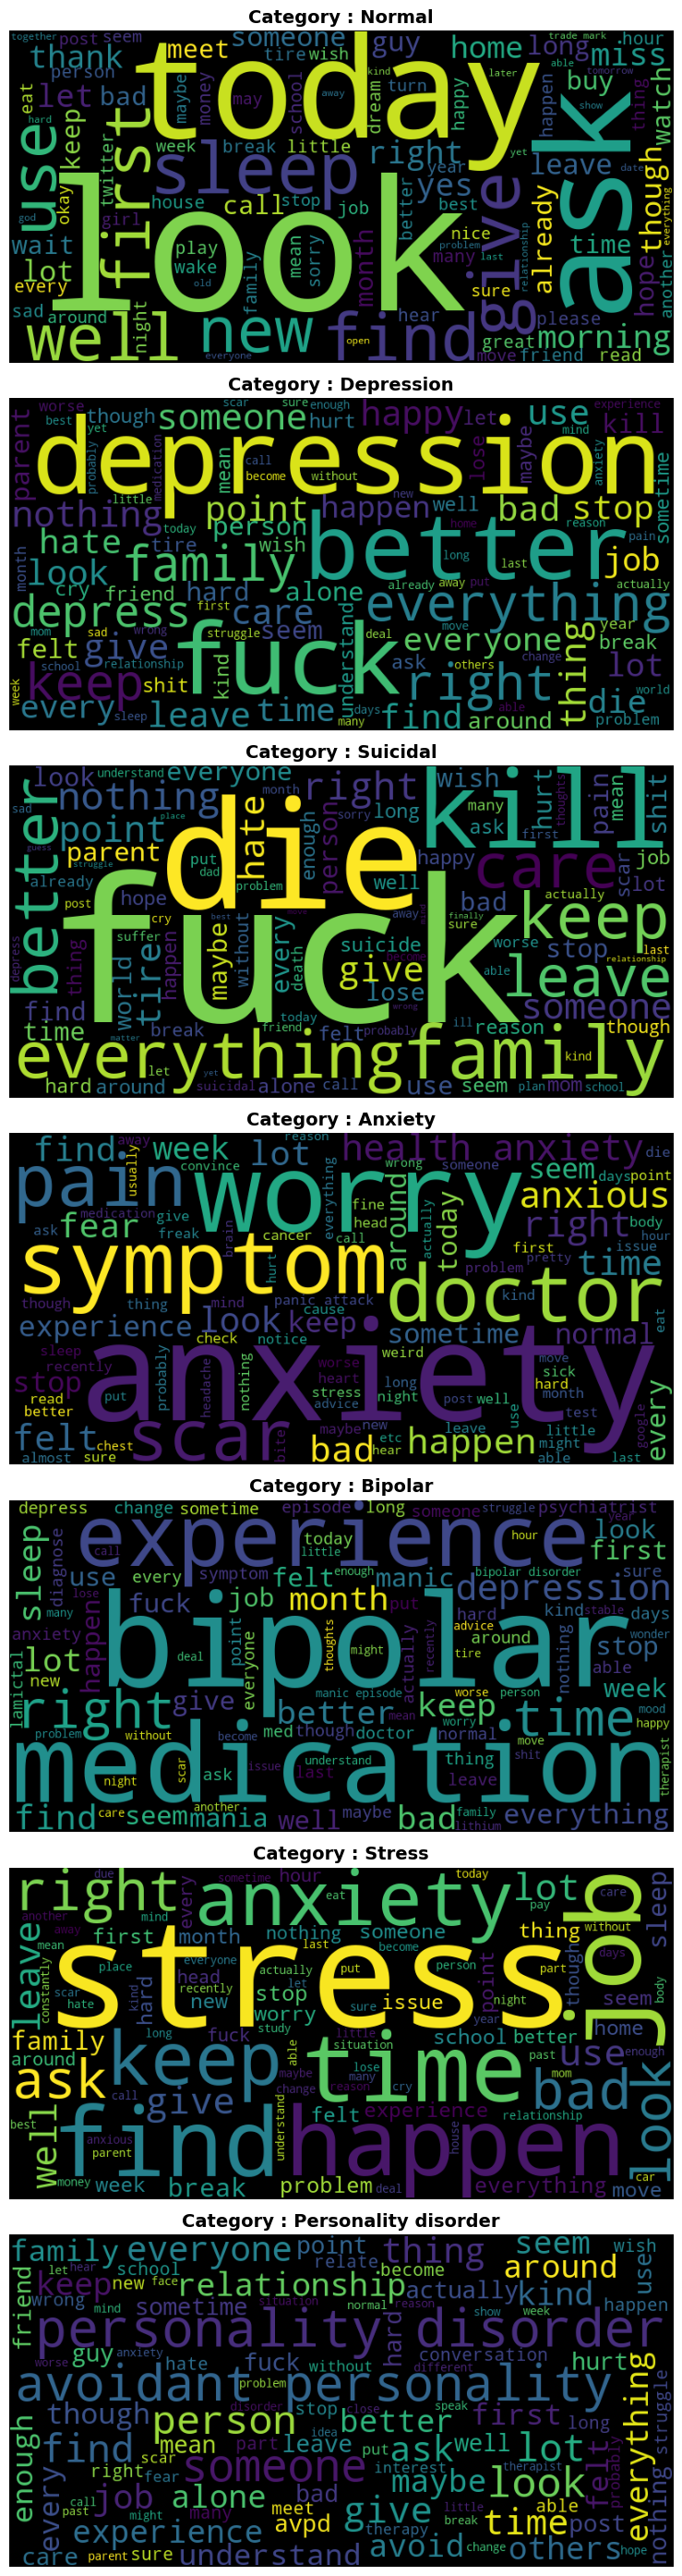

In [91]:
fig,axes = plt.subplots(7,1,figsize=(30,28))
# ax = axes.flatten()
for i, (cat,text) in enumerate(d.items()):
    wc = WordCloud(width=800, height=400, background_color="black",max_words=100).generate(text)
    axes[i].set_title(f"Category : {cat}",fontsize=14,fontweight="bold")
    axes[i].imshow(wc)
    axes[i].axis("off")
# ax[-1].axis("off")
plt.tight_layout()
plt.show()